# 統計モデルの基礎：NumPyによる線形回帰モデルの実装

## 1. 統計モデルとは？
統計モデルとは、現実のデータが「どのようなメカニズム（確率分布や数式）で生成されたか」を仮定し、数式で表現したものです。データに潜むパターンを捉え、未知のデータの予測や、変数間の関係性の解釈に役立てます。

今回は最も基本的な**線形回帰モデル**を扱います。
ある入力変数 $x$ に対して、出力変数 $y$ が線形の関係（直線関係）にあると仮定します。

$$y = \beta_0 + \beta_1 x + \epsilon$$

* $\beta_0$: 切片（バイアス）
* $\beta_1$: 傾き（重み）
* $\epsilon$: 誤差項（モデルでは説明しきれないノイズ。通常、平均0の正規分布に従うと仮定します）

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


## 2. 人工データの生成
まずは、モデルを検証するための「正解が分かっているデータ」をNumPyで作ります。
ここでは真のパラメータを $\beta_0 = 4$（切片）、$\beta_1 = 3$（傾き）とし、そこに正規分布に従うノイズ（$\epsilon$）を加えます。

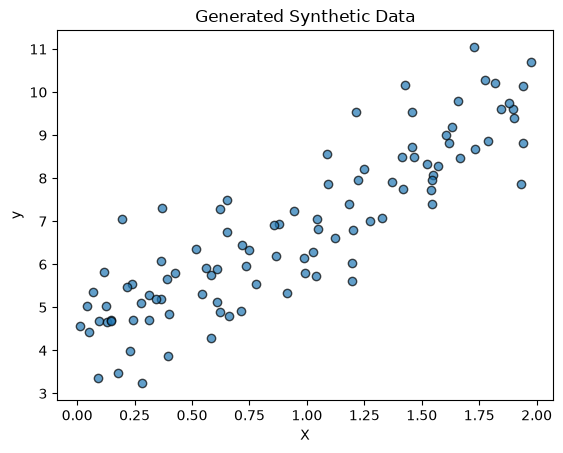

In [2]:
# 乱数のシードを固定（再現性のため）
np.random.seed(42)

# データ数
N = 100

# 0から2の範囲でランダムな x を100個生成
X = 2 * np.random.rand(N, 1)

# 真のパラメータに基づき y を生成（ノイズを追加）
# y = 4 + 3x + ノイズ
true_beta_0 = 4
true_beta_1 = 3
noise = np.random.randn(N, 1) # 標準正規分布に従うノイズ

y = true_beta_0 + true_beta_1 * X + noise

# データの可視化
plt.scatter(X, y, alpha=0.7, edgecolors='k') # リストXとyを座標の組として与えた散布図を作成
plt.xlabel('X') #横軸ラベル
plt.ylabel('y') #縦軸ラベル
plt.title('Generated Synthetic Data') #
plt.show()

## 3. 最小二乗法 (OLS) によるパラメータ推定
手元にあるデータ $(X, y)$ から、未知のパラメータ $\beta$ を推定します。
最も一般的な方法は、予測値と実際の値のズレ（残差）の二乗和を最小化する**最小二乗法（Ordinary Least Squares: OLS）**です。

行列表現を用いると、線形回帰モデルは以下のように書けます。
$$y = X\beta + \epsilon$$

このとき、誤差の二乗和を最小にするパラメータの推定値 $\hat{\beta}$ は、解析的に以下の公式で求まります。
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

これをNumPyの行列演算を使って実装します。
※行列計算のために、入力データ $X$ の左側に「1」が並んだダミーの列（切片用）を追加する必要があります。

In [3]:
# 切片(beta_0)を計算するために、Xのすべての行に x_0 = 1 を追加する
X_b = np.c_[np.ones((N, 1)), X]

# 最小二乗法の公式: (X^T * X)^(-1) * X^T * y
# np.linalg.inv(): 逆行列の計算
# .dot(): 行列の積
beta_hat = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("--- 推定されたパラメータ ---")
print(f"切片 (beta_0): {beta_hat[0][0]:.4f} (真の値: {true_beta_0})")
print(f"傾き (beta_1): {beta_hat[1][0]:.4f} (真の値: {true_beta_1})")

--- 推定されたパラメータ ---
切片 (beta_0): 4.2151 (真の値: 4)
傾き (beta_1): 2.7701 (真の値: 3)


## 4. 推定されたモデルの可視化
計算によって得られたパラメータ $\hat{\beta}$ を使って、直線を引いてみる。
データによくフィットしていることが確認できるはずです。

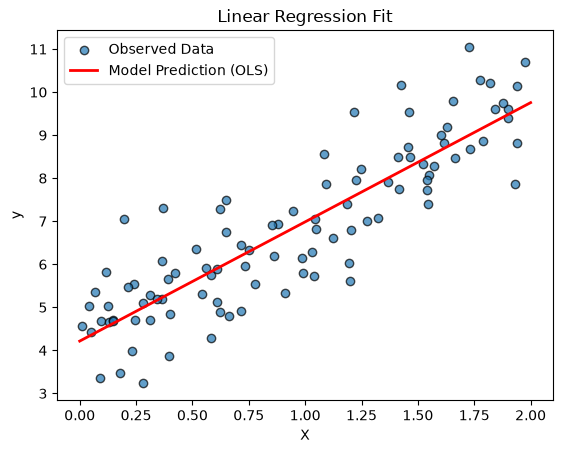

In [4]:
# 予測用の新しいデータポイント（0と2の両端）を作成
X_new = np.array([[0], [2]])

# 切片用に1を追加
X_new_b = np.c_[np.ones((2, 1)), X_new]

# 推定したパラメータを使って予測値を計算
# y_predict = X_new_b * beta_hat
y_predict = X_new_b.dot(beta_hat)

# プロット
plt.scatter(X, y, alpha=0.7, edgecolors='k', label='Observed Data')
plt.plot(X_new, y_predict, color='red', linewidth=2, label='Model Prediction (OLS)')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()

## 演習：広告費から売上を予測する統計モデルを作ろう

ある店舗で、過去10日間の「広告費（万円）」と「売上（万円）」の記録があります。

| 広告費(x) | 1.0 | 2.0 | 3.0 | 4.0 | 5.0 | 6.0 | 7.0 | 8.0 | 9.0 | 10.0 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 売上(y) | 2.5 | 4.8 | 6.2 | 8.9 | 10.5 | 12.1 | 14.8 | 15.2 | 18.1 | 20.5 |



### 課題
1. **パラメータの推定**: 
   与えられたデータを用いて、最小二乗法により最適な切片（$\beta_0$）と傾き（$\beta_1$）を求めてください。
   
2. **予測**: 
   推定されたモデル式を用いて、「広告費を12万円投入した場合の売上予測値」を計算してください。

### ヒント
* 最小二乗法の公式: $\hat{\beta} = (X^T X)^{-1} X^T y$

---



In [ ]:
import numpy as np

# データの入力
x = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
y = np.array([2.5, 4.8, 6.2, 8.9, 10.5, 12.1, 14.8, 15.2, 18.1, 20.5])

# 1. 最小二乗法のための行列構築
# xの各要素に切片用の1を結合して行列にする
X = np.c_[np.ones(x.shape[0]), x]

beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y #公式による
beta_hat

array([0.71333333, 1.93575758])

In [20]:
#2. 予測
#広告費12万円のときの売上予測
y_estimated = beta_hat[1] * 12 + beta_hat[0]
# i.e.
y_estimated = np.array([1, 12]) @ beta_hat

y_estimated

np.float64(23.94242424242425)